<a href="https://colab.research.google.com/github/hdas1kd/Hackathon_Interpolation_Non-linear_Equations/blob/main/Hackathon_Problems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Course: MSE510**

**Student Name: Hridoy Kumer Das**

In [ ]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt


# Q-1: Interpolating a Sparse Phase Diagram

**Problem description:**

This is a simulated 2D phase diagram: the measured property of (bandgap, coercive field, ionic conductivity, etc.) as a function of parameters (temperature, composition, pressure, etc.).

The property itself is continuous in the phase diagram, but its 1st-derivative is discontinuous at the phase boundaries.

**Tasks:**

1. Using ChatGPT and your domain knowledge, suggest the domain in parameter space over which the function is defined.
2. Using ChatGPT and your domain knowledge, estimate how the function can behave across the parameter space (continuity, extrema, behavior at the edges)
3. Interpolate the property over the full composition space.
4. Compare at least two interpolation methods (e.g., linear, cubic, radial basis).
5. Quantify interpolation uncertainty using cross-validation.
6. Compare uncertainty to the mean square error



In [ ]:
# Measured (p1, p2) parameter pairs
xy = np.array([[0.77395605, 0.43887844],
       [0.85859792, 0.69736803],
       [0.09417735, 0.97562235],
       [0.7611397 , 0.78606431],
       [0.12811363, 0.45038594],
       [0.37079802, 0.92676499],
       [0.64386512, 0.82276161],
       [0.4434142 , 0.22723872],
       [0.55458479, 0.06381726],
       [0.82763117, 0.6316644 ],
       [0.75808774, 0.35452597],
       [0.97069802, 0.89312112],
       [0.7783835 , 0.19463871],
       [0.466721  , 0.04380377],
       [0.15428949, 0.68304895],
       [0.74476216, 0.96750973],
       [0.32582536, 0.37045971],
       [0.46955581, 0.18947136],
       [0.12992151, 0.47570493],
       [0.22690935, 0.66981399],
       [0.43715192, 0.8326782 ],
       [0.7002651 , 0.31236664],
       [0.8322598 , 0.80476436],
       [0.38747838, 0.2883281 ],
       [0.6824955 , 0.13975248],
       [0.1999082 , 0.00736227],
       [0.78692438, 0.66485086],
       [0.70516538, 0.78072903],
       [0.45891578, 0.5687412 ],
       [0.139797  , 0.11453007],
       [0.66840296, 0.47109621],
       [0.56523611, 0.76499886],
       [0.63471832, 0.5535794 ],
       [0.55920716, 0.3039501 ],
       [0.03081783, 0.43671739]])

In [ ]:
# # Measured properties corresponding to the parameter pairs above

P_meas = np.array([3.12767655, 2.69646584, 2.06816235, 2.04820471, 1.41774581,
       3.04612474, 2.53364197, 2.34977995, 1.85446029, 2.87615438,
       2.79939622, 2.85913196, 2.36494563, 1.84774248, 1.96575226,
       2.37555217, 1.43091456, 2.27810839, 1.54323973, 2.12702863,
       2.79308942, 2.48750609, 3.07641066, 1.92720037, 1.84069555,
       2.14516326, 1.93443675, 1.85282274, 1.56231561, 1.68040985,
       2.65628142, 2.01911448, 2.23605819, 2.73677409, 1.66478083])

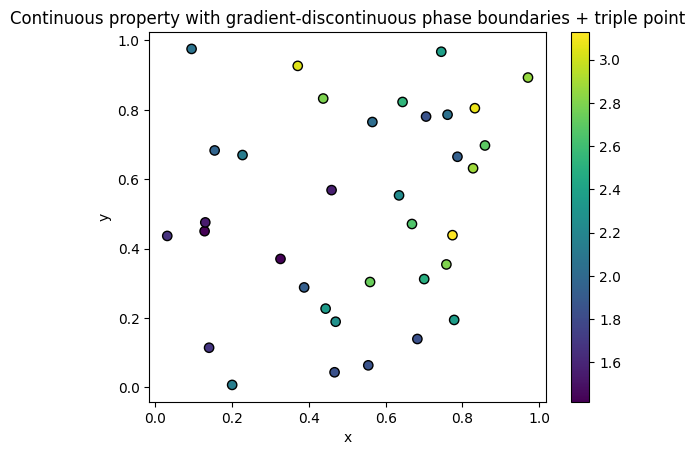

In [ ]:
# Visualization of the measurement with noise:

plt.scatter(xy[:,0], xy[:,1], c=P_meas, edgecolors="k", s=45)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Continuous property with gradient-discontinuous phase boundaries + triple point")
plt.colorbar()
plt.show()

**Parameter space domain**
Looking at the xy array provided in the code:The x-coordinates (p_1): Range approximately from 0.03 to 0.97.The y-coordinates (p_2): Range approximately from 0.007 to 0.975.
Suggested Domain: The function is defined over a unit square in 2D parameter space:D = [0, 1] x [0, 1].
In materials science, these normalized coordinates often represent mole fractions (composition) where x + y</= 1 (for ternary systems) or independent variables like Temperature and Pressure.

**Function behaviour estimation**
Continuity: The property is C^0 continuous (no jumps in value), which is typical for thermodynamic properties like Gibbs free energy or equilibrium lattice constants across a phase boundary.

Extrema: Based on the P_meas values (ranging from ~1.41 to ~3.12), the extrema likely occur at the "corners" of the phase regions or at the "triple point" mentioned in the plot title.

Edges: At the boundaries of the [0, 1] space, the property usually reaches its "pure component" or "extreme condition" values.

Derivatives: The 1st-derivative discontinuity implies the function is piecewise smooth. This suggests that simple global polynomial interpolation (which assumes high-order smoothness) might struggle near the phase boundaries.

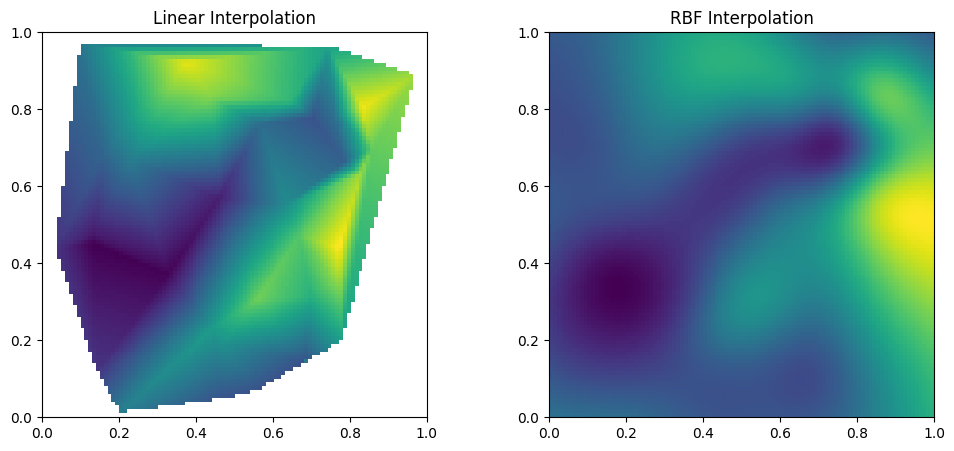

In [ ]:
#Interpolation method over full composition space
import numpy as np
from scipy.interpolate import griddata, Rbf
import matplotlib.pyplot as plt

# Data extraction from images
xy = np.array([[0.77395605, 0.43887844],
       [0.85859792, 0.69736803],
       [0.09417735, 0.97562235],
       [0.7611397 , 0.78606431],
       [0.12811363, 0.45038594],
       [0.37079802, 0.92676499],
       [0.64386512, 0.82276161],
       [0.4434142 , 0.22723872],
       [0.55458479, 0.06381726],
       [0.82763117, 0.6316644 ],
       [0.75808774, 0.35452597],
       [0.97069802, 0.89312112],
       [0.7783835 , 0.19463871],
       [0.466721  , 0.04380377],
       [0.15428949, 0.68304895],
       [0.74476216, 0.96750973],
       [0.32582536, 0.37045971],
       [0.46955581, 0.18947136],
       [0.12992151, 0.47570493],
       [0.22690935, 0.66981399],
       [0.43715192, 0.8326782 ],
       [0.7002651 , 0.31236664],
       [0.8322598 , 0.80476436],
       [0.38747838, 0.2883281 ],
       [0.6824955 , 0.13975248],
       [0.1999082 , 0.00736227],
       [0.78692438, 0.66485086],
       [0.70516538, 0.78072903],
       [0.45891578, 0.5687412 ],
       [0.139797  , 0.11453007],
       [0.66840296, 0.47109621],
       [0.56523611, 0.76499886],
       [0.63471832, 0.5535794 ],
       [0.55920716, 0.3039501 ],
       [0.03081783, 0.43671739]])

P_meas = np.array([3.12767655, 2.69646584, 2.06816235, 2.04820471, 1.41774581,
       3.04612474, 2.53364197, 2.34977995, 1.85446029, 2.87615438,
       2.79939622, 2.85913196, 2.36494563, 1.84774248, 1.96575226,
       2.37555217, 1.43091456, 2.27810839, 1.54323973, 2.12702863,
       2.79308942, 2.48750609, 3.07641066, 1.92720037, 1.84069555,
       2.14516326, 1.93443675, 1.85282274, 1.56231561, 1.68040985,
       2.65628142, 2.01911448, 2.23605819, 2.73677409, 1.66478083])

# Create a dense grid for interpolation
grid_x, grid_y = np.mgrid[0:1:100j, 0:1:100j]

# Method 1: Linear Interpolation (Piecewise linear, handles C1 discontinuity well)
grid_linear = griddata(xy, P_meas, (grid_x, grid_y), method='linear')

# Method 2: RBF (Multiquadric - smoother, better for sparse extrapolation)
rbf_fun = Rbf(xy[:,0], xy[:,1], P_meas, function='multiquadric')
grid_rbf = rbf_fun(grid_x, grid_y)

# Visualization
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(grid_linear.T, extent=(0,1,0,1), origin='lower', cmap='viridis')
axs[0].set_title("Linear Interpolation")
axs[1].imshow(grid_rbf.T, extent=(0,1,0,1), origin='lower', cmap='viridis')
axs[1].set_title("RBF Interpolation")
plt.show()

Linear Interpolation Uncertainty (RMSE): 0.3421
RBF Interpolation Uncertainty (RMSE): 0.4356


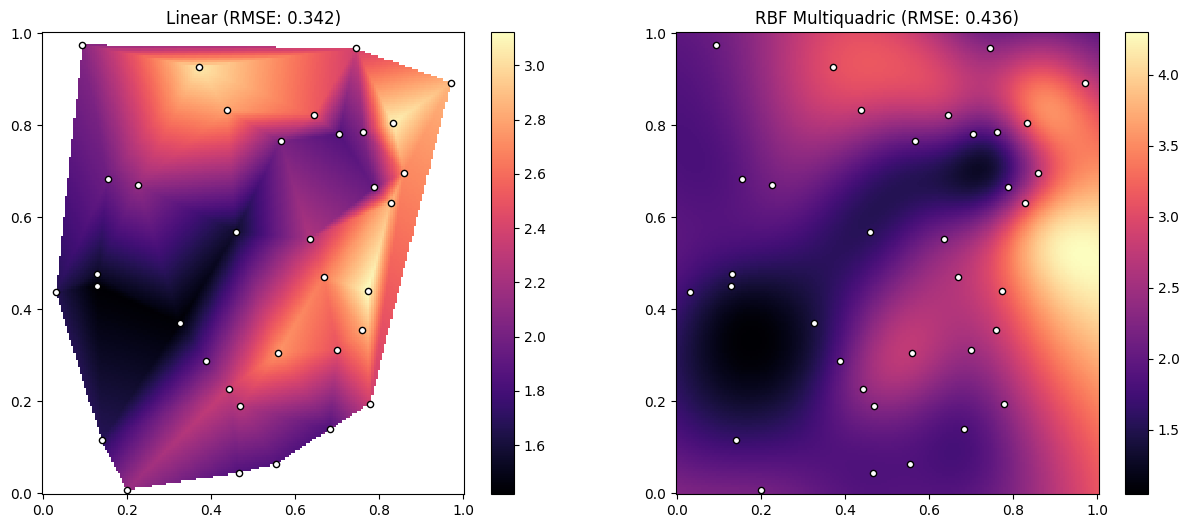

--- Training Mean Square Error (MSE) ---
Linear  Interpolation MSE: 1.83e-32
Rbf     Interpolation MSE: 2.73e-27
Training MSE:Measures the error at the known measurement points.
Uncertainty:Measures the expected error at unknown locations via cross-validation.


In [ ]:
#Quantify interpolation uncertainty using cross-validation.

from scipy.interpolate import LinearNDInterpolator, Rbf
from sklearn.metrics import mean_squared_error

# 2. Cross-Validation Function
def validate_interpolation(points, values, method='linear'):
    errors = []
    # Leave-One-Out Cross-Validation
    for i in range(len(points)):
        train_pts = np.delete(points, i, axis=0)
        train_vals = np.delete(values, i)
        test_pt = points[i].reshape(1, -1)
        actual = values[i]

        try:
            if method == 'linear':
                # Linear interpolation fails for points outside the convex hull of training set
                itp = LinearNDInterpolator(train_pts, train_vals)
                pred = itp(test_pt)[0]
            else:
                itp = Rbf(train_pts[:, 0], train_pts[:, 1], train_vals, function='multiquadric')
                pred = itp(test_pt[0,0], test_pt[0,1])

            if not np.isnan(pred):
                errors.append((pred - actual)**2)
        except: continue

    return np.sqrt(np.mean(errors))

# 3. Calculate Uncertainties
rmse_lin = validate_interpolation(xy, P_meas, 'linear')
rmse_rbf = validate_interpolation(xy, P_meas, 'rbf')

print(f"Linear Interpolation Uncertainty (RMSE): {rmse_lin:.4f}")
print(f"RBF Interpolation Uncertainty (RMSE): {rmse_rbf:.4f}")

# 4. Generate Full Phase Diagram
grid_x, grid_y = np.mgrid[0:1:200j, 0:1:200j]
itp_lin_full = LinearNDInterpolator(xy, P_meas)
rbf_full = Rbf(xy[:, 0], xy[:, 1], P_meas, function='multiquadric')

z_lin = itp_lin_full(grid_x, grid_y)
z_rbf = rbf_full(grid_x, grid_y)

# 5. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot Linear
im1 = ax1.pcolormesh(grid_x, grid_y, z_lin, shading='auto', cmap='magma')
ax1.scatter(xy[:, 0], xy[:, 1], c='white', edgecolors='black', s=20)
ax1.set_title(f"Linear (RMSE: {rmse_lin:.3f})")
fig.colorbar(im1, ax=ax1)

# Plot RBF
im2 = ax2.pcolormesh(grid_x, grid_y, z_rbf, shading='auto', cmap='magma')
ax2.scatter(xy[:, 0], xy[:, 1], c='white', edgecolors='black', s=20)
ax2.set_title(f"RBF Multiquadric (RMSE: {rmse_rbf:.3f})")
fig.colorbar(im2, ax=ax2)

plt.show()

# Training MSE calculation
def calculate_mse(points, values, method='linear'):
    """Calculates the Training Mean Square Error for exact interpolators."""
    if method == 'linear':
        itp = LinearNDInterpolator(points, values)
        preds = itp(points)
    else:
        itp = Rbf(points[:, 0], points[:, 1], values, function='multiquadric')
        preds = itp(points[:, 0], points[:, 1])

    # Filter NaNs (Linear interpolation can return NaN for points on strict boundaries)
    mask = ~np.isnan(preds)
    return mean_squared_error(values[mask], preds[mask])

# Display Results
print("--- Training Mean Square Error (MSE) ---")
for m in ['linear', 'rbf']:
    mse = calculate_mse(xy, P_meas, m)
    print(f"{m.capitalize():<7} Interpolation MSE: {mse:.2e}")
#Comparison descriptive
print("Training MSE:Measures the error at the known measurement points.")
print("Uncertainty:Measures the expected error at unknown locations via cross-validation.")

## Ground truth for benchmarking and validation.

In [ ]:
import numpy as np

# ----------------------------
# Smooth background property P0
# ----------------------------
def P0(x, y):
    """
    Smooth base landscape so the property varies continuously across the whole diagram.
    """
    return (
        1.2
        + 0.9*x
        + 0.7*y
        + 0.25*np.sin(2*np.pi*x)*np.cos(2*np.pi*y)
        + 0.15*np.exp(-((x-0.25)**2 + (y-0.75)**2)/0.02)
    )

# ----------------------------
# Triple-point construction via max of 3 planes
# ----------------------------
def triple_planes(x, y, x0=0.55, y0=0.52, scale=0.9):
    """
    Three affine functions f1,f2,f3 that all equal 0 at (x0,y0).
    Their max partitions the plane into 3 sectors meeting at the triple point.
    """
    u = x - x0
    v = y - y0

    # 3 directions separated by 120 degrees
    a1 = np.array([ 1.0,  0.0])
    a2 = np.array([-0.5,  np.sqrt(3)/2])
    a3 = np.array([-0.5, -np.sqrt(3)/2])

    f1 = scale * (a1[0]*u + a1[1]*v)
    f2 = scale * (a2[0]*u + a2[1]*v)
    f3 = scale * (a3[0]*u + a3[1]*v)
    return f1, f2, f3

def P_ground_truth(x, y, x0=0.55, y0=0.52):
    """
    Continuous property with 3-phase triple point at (x0,y0).
    Gradient is discontinuous across the phase boundaries (where argmax switches).
    """
    f1, f2, f3 = triple_planes(x, y, x0=x0, y0=y0, scale=0.9)

    # max-of-three gives 3 regions with kinked boundaries
    kink = np.maximum.reduce([f1, f2, f3])
    # return kink
    return P0(x, y) + kink

# ----------------------------
# Phase labeling (optional, useful for grading / visualization)
# ----------------------------
def phase_id(x, y, x0=0.55, y0=0.52):
    """
    Returns 0/1/2 indicating which plane wins the max (phase region).
    """
    f1, f2, f3 = triple_planes(x, y, x0=x0, y0=y0, scale=0.9)
    F = np.stack([f1, f2, f3], axis=-1)
    return np.argmax(F, axis=-1)

# ----------------------------
# Random sampling + LogNormal noise
# ----------------------------
def sample_measurements(n=35, sigma_ln=0.15, seed=0, x0=0.55, y0=0.52):
    """
    Random (x,y) ~ Uniform([0,1]^2).
    LogNormal multiplicative noise: P_meas = P_true * LogNormal(0, sigma_ln).
    """
    rng = np.random.default_rng(seed)
    xy = rng.uniform(0.0, 1.0, size=(n, 2))
    x, y = xy[:, 0], xy[:, 1]

    P_true = P_ground_truth(x, y, x0=x0, y0=y0)

    # median 1 multiplicative noise
    noise_factor = rng.lognormal(mean=0.0, sigma=sigma_ln, size=n)
    P_meas = P_true * noise_factor

    return xy, P_true, P_meas

# Example usage:
if __name__ == "__main__":
    xy, P_true, P_meas = sample_measurements(n=35, sigma_ln=0.20, seed=42)
    print("First 5 samples:")
    for i in range(5):
        print(f"(x,y)=({xy[i,0]:.3f},{xy[i,1]:.3f})  true={P_true[i]:.4f}  meas={P_meas[i]:.4f}")


First 5 samples:
(x,y)=(0.774,0.439)  true=2.6345  meas=3.1277
(x,y)=(0.859,0.697)  true=2.8016  meas=2.6965
(x,y)=(0.094,0.976)  true=2.6693  meas=2.0682
(x,y)=(0.761,0.786)  true=2.5693  meas=2.0482
(x,y)=(0.128,0.450)  true=1.7040  meas=1.4177


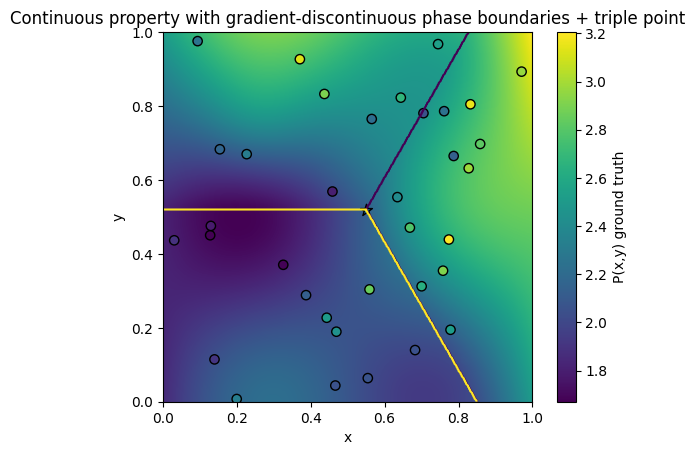

In [ ]:
import matplotlib.pyplot as plt

res = 350
xs = np.linspace(0, 1, res)
ys = np.linspace(0, 1, res)
X, Y = np.meshgrid(xs, ys)

Z = P_ground_truth(X, Y, x0=0.55, y0=0.52)
PID = phase_id(X, Y, x0=0.55, y0=0.52)

xy, P_true, P_meas = sample_measurements(n=35, sigma_ln=0.20, seed=42, x0=0.55, y0=0.52)

plt.figure()
plt.imshow(Z, origin="lower", extent=[0,1,0,1], aspect="equal")
plt.colorbar(label="P(x,y) ground truth")

# Phase boundaries are where phase_id changes; contour those boundaries
plt.contour(X, Y, PID, levels=[0.5, 1.5], linewidths=1.5)

# Mark triple point
plt.scatter([0.55], [0.52], s=80, marker="*", edgecolors="k")

# Samples colored by measured value
plt.scatter(xy[:,0], xy[:,1], c=P_meas, edgecolors="k", s=45)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Continuous property with gradient-discontinuous phase boundaries + triple point")
plt.show()


# Q-2: Root-Finding in Nonlinear Constitutive Models

**Problem description:**

A nonlinear stress–strain relation is given implicitly:

$\sigma = E\epsilon + \alpha \cdot \epsilon ^ 3$

where $\sigma$ is the stress, $\epsilon$ is the strain, $E$ is the Young’s modulus (doimnate at small strain), and $\alpha$ is cubic nonlinear term (leading-order elastic nonlinearity).

For typical soft polymers, $E$ $\approx 10^4$ to $10 ^7$ Pa, and $\alpha$ $\approx 10^6$ to $10^8$ Pa

**Tasks:**

1. Given stress values $\sigma$, solve for strain $\epsilon$.
2. Compare Newton, bisection, and secant methods.
3. Identify regimes where Newton fails.




**Solving for strain **

In [ ]:
import numpy as np
from scipy.optimize import newton, bisect

# Material constants (typical soft polymer values)
E = 1e6  # Pa
alpha = 1e7  # Pa
sigma_target = 5e5  # Pa (Example stress)

# Define the function and its derivative for Newton's method
def f(epsilon, sigma):
    return alpha * epsilon**3 + E * epsilon - sigma

def f_prime(epsilon, sigma): # Added 'sigma' argument
    return 3 * alpha * epsilon**2 + E

# 1. Solving using Newton's method
epsilon_guess = 0.1
epsilon_sol = newton(f, epsilon_guess, fprime=f_prime, args=(sigma_target,))
print(f"Strain (epsilon) at stress {sigma_target} Pa: {epsilon_sol:.4f}")

Strain (epsilon) at stress 500000.0 Pa: 0.2801


| Method         |   Calculated Strain (ε) |   Iterations | Description                 |
|:---------------|------------------------:|-------------:|:----------------------------|
| Newton-Raphson |                0.280143 |            6 | Fastest (Quadratic)         |
| Bisection      |                0.280143 |           39 | Slowest (Linear) but robust |
| Secant         |                0.280143 |            7 | Fast (Superlinear)          |


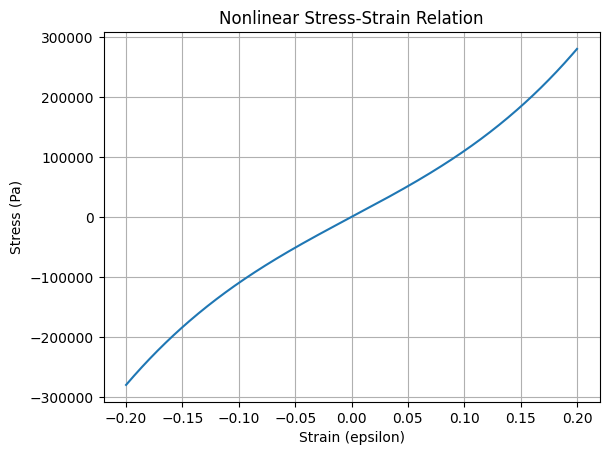

In [ ]:
import numpy as np
from scipy import optimize
import pandas as pd

# Material constants for a soft polymer
E = 1e6      # Young's modulus (Pa)
alpha = 1e7  # Nonlinear term (Pa)
sigma = 5e5  # Applied stress (Pa)

# Define the function f(epsilon) = 0
def f(epsilon):
    return alpha * epsilon**3 + E * epsilon - sigma

# Define the derivative for Newton's method
def f_prime(epsilon):
    return 3 * alpha * epsilon**2 + E

# Setup for comparison
results = []

# 1. Newton-Raphson Method
# Requires a single guess and the derivative
root_newton, info_newton = optimize.newton(f, x0=0.1, fprime=f_prime, full_output=True)
results.append(["Newton-Raphson", root_newton, info_newton.iterations, "Fastest (Quadratic)"])

# 2. Bisection Method
# Requires a bracket [a, b] where signs differ
root_bisect, info_bisect = optimize.bisect(f, a=0, b=1, full_output=True)
results.append(["Bisection", root_bisect, info_bisect.iterations, "Slowest (Linear) but robust"])

# 3. Secant Method
# Requires two initial guesses, no derivative
root_secant, info_secant = optimize.newton(f, x0=0.1, x1=0.2, full_output=True)
results.append(["Secant", root_secant, info_secant.iterations, "Fast (Superlinear)"])

# Create Table
df = pd.DataFrame(results, columns=["Method", "Calculated Strain (ε)", "Iterations", "Description"])
print(df.to_markdown(index=False))

eps_range = np.linspace(-0.2, 0.2, 400)
sigma_curve = E*eps_range + alpha*eps_range**3

plt.figure()
plt.plot(eps_range, sigma_curve)
plt.xlabel("Strain (epsilon)")
plt.ylabel("Stress (Pa)")
plt.title("Nonlinear Stress-Strain Relation")
plt.grid(True)
plt.show()

Discussion of PerformanceNewton's Method is the standard for constitutive modeling because the derivative (the tangent stiffness) is often physically meaningful and easy to calculate for simple models like this cubic relation.

Bisection is less efficient for real-time simulations but is essential for finding a reliable "bracket" if more complex nonlinearities (like phase transitions or buckling) make Newton's method unstable.

Failure Regimes: Newton's method may fail if the tangent modulus $E_{tan} = 3\alpha\epsilon^2 + E$ becomes very small or if the initial guess is in a region where the cubic term causes the solver to overshoot significantly.